# 🔊 EDA - Phân Tích Dữ Liệu Sonar Returns
**Môn:** Machine Learning  
**Bài toán:** Binary Classification – Mine (M) vs Rock (R)  
**Dataset dùng xuyên suốt:** sonar.csv  
**Mục tiêu mới:** EDA → Train → Test đều dùng chung bộ dữ liệu Sonar


# 1. Định nghĩa vấn đề
- Phân tích yêu cầu cụ thể của bài toán là gì?
- Xác định đầu vào (Input): các tính chất (features) dùng để phân loại mẫu (pattern)
- Xác định đầu ra (Output): dữ liệu phân lớp (classification) hay hồi qui (regression)

# 2. Chuẩn bị vấn đề

## 2.1. Khai báo thư viện & Tham số thực nghiệm

In [1]:
# ── Thư viện ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Tham số thực nghiệm ─────────────────────────────────
DATA_NAME = 'sonar' 

BASE_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..'))              if os.path.basename(os.getcwd()) == 'prj'              else os.getcwd()

DATA_PATH   = os.path.join(BASE_DIR, 'data', f'{DATA_NAME}.csv')
PROJECT_DIR = os.path.join(BASE_DIR, 'exps_', DATA_NAME)
os.makedirs(PROJECT_DIR, exist_ok=True)

COL_NAMES    = [f'F{i+1:02d}' for i in range(60)] + ['class']
FEATURES     = [f'F{i+1:02d}' for i in range(60)]
TEST_SIZE    = 0.30
RANDOM_STATE = 42

# ── Đường dẫn output dùng chung cho train/test ──────────
EDA_LOG         = os.path.join(PROJECT_DIR, 'eda_log.xlsx')
TRAIN_DATA_RAW  = os.path.join(PROJECT_DIR, 'train_raw.csv')
TEST_DATA_RAW   = os.path.join(PROJECT_DIR, 'test_raw.csv')
TRAIN_DATA_MM   = os.path.join(PROJECT_DIR, 'train_minmax.csv')
TEST_DATA_MM    = os.path.join(PROJECT_DIR, 'test_minmax.csv')
TRAIN_DATA_STD  = os.path.join(PROJECT_DIR, 'train_standard.csv')
TEST_DATA_STD   = os.path.join(PROJECT_DIR, 'test_standard.csv')
SPLIT_META      = os.path.join(PROJECT_DIR, 'split_metadata.json')
CUSTOM_TEMPLATE = os.path.join(PROJECT_DIR, 'custom_test_template.csv')

print('✅ Cấu hình EDA mới đã sẵn sàng')
print(f'   DATA_PATH   : {DATA_PATH}')
print(f'   PROJECT_DIR : {PROJECT_DIR}')
print('   Flow dùng chung: EDA → Train → Test trên Sonar')


✅ Cấu hình EDA mới đã sẵn sàng
   DATA_PATH   : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\data\sonar.csv
   PROJECT_DIR : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar
   Flow dùng chung: EDA → Train → Test trên Sonar


# 3. Phân tích dữ liệu

## 3.1. Thống kê mô tả về dữ liệu

### 3.1.1 Kích thước dữ liệu

In [2]:
df = pd.read_csv(DATA_PATH, header=None, names=COL_NAMES)

print(f'Shape: {df.shape}  ({df.shape[0]} dòng x {df.shape[1]} cột)')
print(f'Tên cột (5 đầu + label): {COL_NAMES[:5]} ... {COL_NAMES[-1]}')
df.head(5)


Shape: (208, 61)  (208 dòng x 61 cột)
Tên cột (5 đầu + label): ['F01', 'F02', 'F03', 'F04', 'F05'] ... class


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F52,F53,F54,F55,F56,F57,F58,F59,F60,class
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


### 3.1.2. Kiểu dữ liệu của từng thuộc tính

In [3]:
print('=== THÔNG TIN DATASET ===')
df.info()

=== THÔNG TIN DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F01     208 non-null    float64
 1   F02     208 non-null    float64
 2   F03     208 non-null    float64
 3   F04     208 non-null    float64
 4   F05     208 non-null    float64
 5   F06     208 non-null    float64
 6   F07     208 non-null    float64
 7   F08     208 non-null    float64
 8   F09     208 non-null    float64
 9   F10     208 non-null    float64
 10  F11     208 non-null    float64
 11  F12     208 non-null    float64
 12  F13     208 non-null    float64
 13  F14     208 non-null    float64
 14  F15     208 non-null    float64
 15  F16     208 non-null    float64
 16  F17     208 non-null    float64
 17  F18     208 non-null    float64
 18  F19     208 non-null    float64
 19  F20     208 non-null    float64
 20  F21     208 non-null    float64
 21  F22     208 n

### 3.1.3. Thống kê mô tả

In [4]:
print('=== THỐNG KÊ MÔ TẢ (10 feature đầu) ===')
df[FEATURES[:10]].describe().round(4)
# thêm cái cuối

=== THỐNG KÊ MÔ TẢ (10 feature đầu) ===


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10
count,208.0000,208.0000,208.0000,208.0000,208.0000,208.0000,208.0000,208.0000,208.0000,208.0000
mean,0.0292,0.0384,0.0438,0.0539,0.0752,0.1046,0.1217,0.1348,0.1780,0.2083
std,0.0230,0.0330,0.0384,0.0465,0.0556,0.0591,0.0618,0.0852,0.1184,0.1344
min,0.0015,0.0006,0.0015,0.0058,0.0067,0.0102,0.0033,0.0055,0.0075,0.0113
25%,0.0134,0.0164,0.0190,0.0244,0.0380,0.0670,0.0809,0.0804,0.0970,0.1113
50%,0.0228,0.0308,0.0343,0.0440,0.0625,0.0922,0.1070,0.1121,0.1522,0.1824
75%,0.0356,0.0480,0.0580,0.0645,0.1003,0.1341,0.1540,0.1696,0.2334,0.2687
max,0.1371,0.2339,0.3059,0.4264,0.4010,0.3823,0.3729,0.4590,0.6828,0.7106


### 3.1.4. Kiểm tra Missing Values & Duplicates

In [5]:
print('=== MISSING VALUES ===')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
df_missing  = pd.DataFrame({'Số thiếu': missing, '% thiếu': missing_pct})
print(df_missing[df_missing['Số thiếu'] > 0])
print(f'→ Tổng missing: {missing.sum()}')

print(f'\n=== DUPLICATES ===')
dup = df.duplicated().sum()
print(f'Số dòng trùng lặp: {dup}')
if dup > 0:
    print('⚠️  Có dòng trùng lặp!')
else:
    print('✅ Không có dòng trùng lặp')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Số thiếu, % thiếu]
Index: []
→ Tổng missing: 0

=== DUPLICATES ===
Số dòng trùng lặp: 0
✅ Không có dòng trùng lặp


### 3.1.5. Phân phối nhãn (Class Distribution)

=== PHÂN PHỐI LỚP ===
class
M    111
R     97
Name: count, dtype: int64
Ratio M/R = 1.14


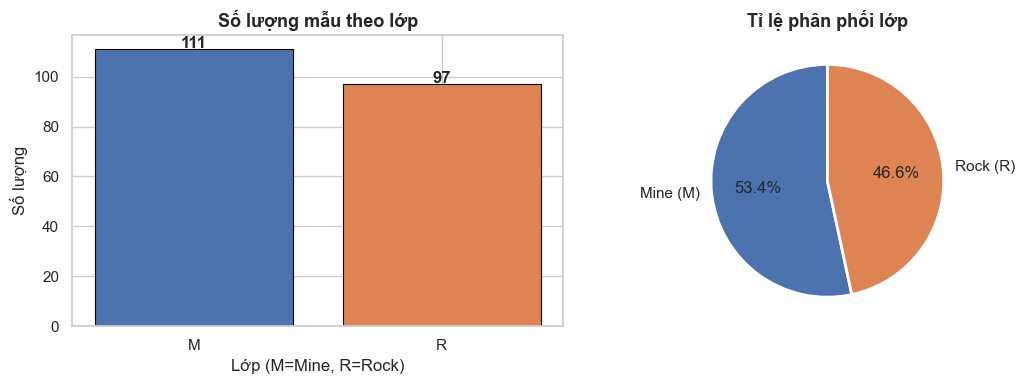

→ Dữ liệu gần cân bằng: Mine=111, Rock=97


In [6]:
class_counts = df['class'].value_counts()
print('=== PHÂN PHỐI LỚP ===')
print(class_counts)
print(f'Ratio M/R = {class_counts["M"]/class_counts["R"]:.2f}')

colors = ['#4C72B0', '#DD8452']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values,
            color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Số lượng mẫu theo lớp', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lớp (M=Mine, R=Rock)')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Mine (M)', 'Rock (R)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỉ lệ phân phối lớp', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_class_distribution.png'), bbox_inches='tight')
plt.show()
print(f'→ Dữ liệu gần cân bằng: Mine={class_counts["M"]}, Rock={class_counts["R"]}')

## 3.2. Hiện thị dữ liệu

### 3.2.1. Phân phối từng feature (Histogram Grid)

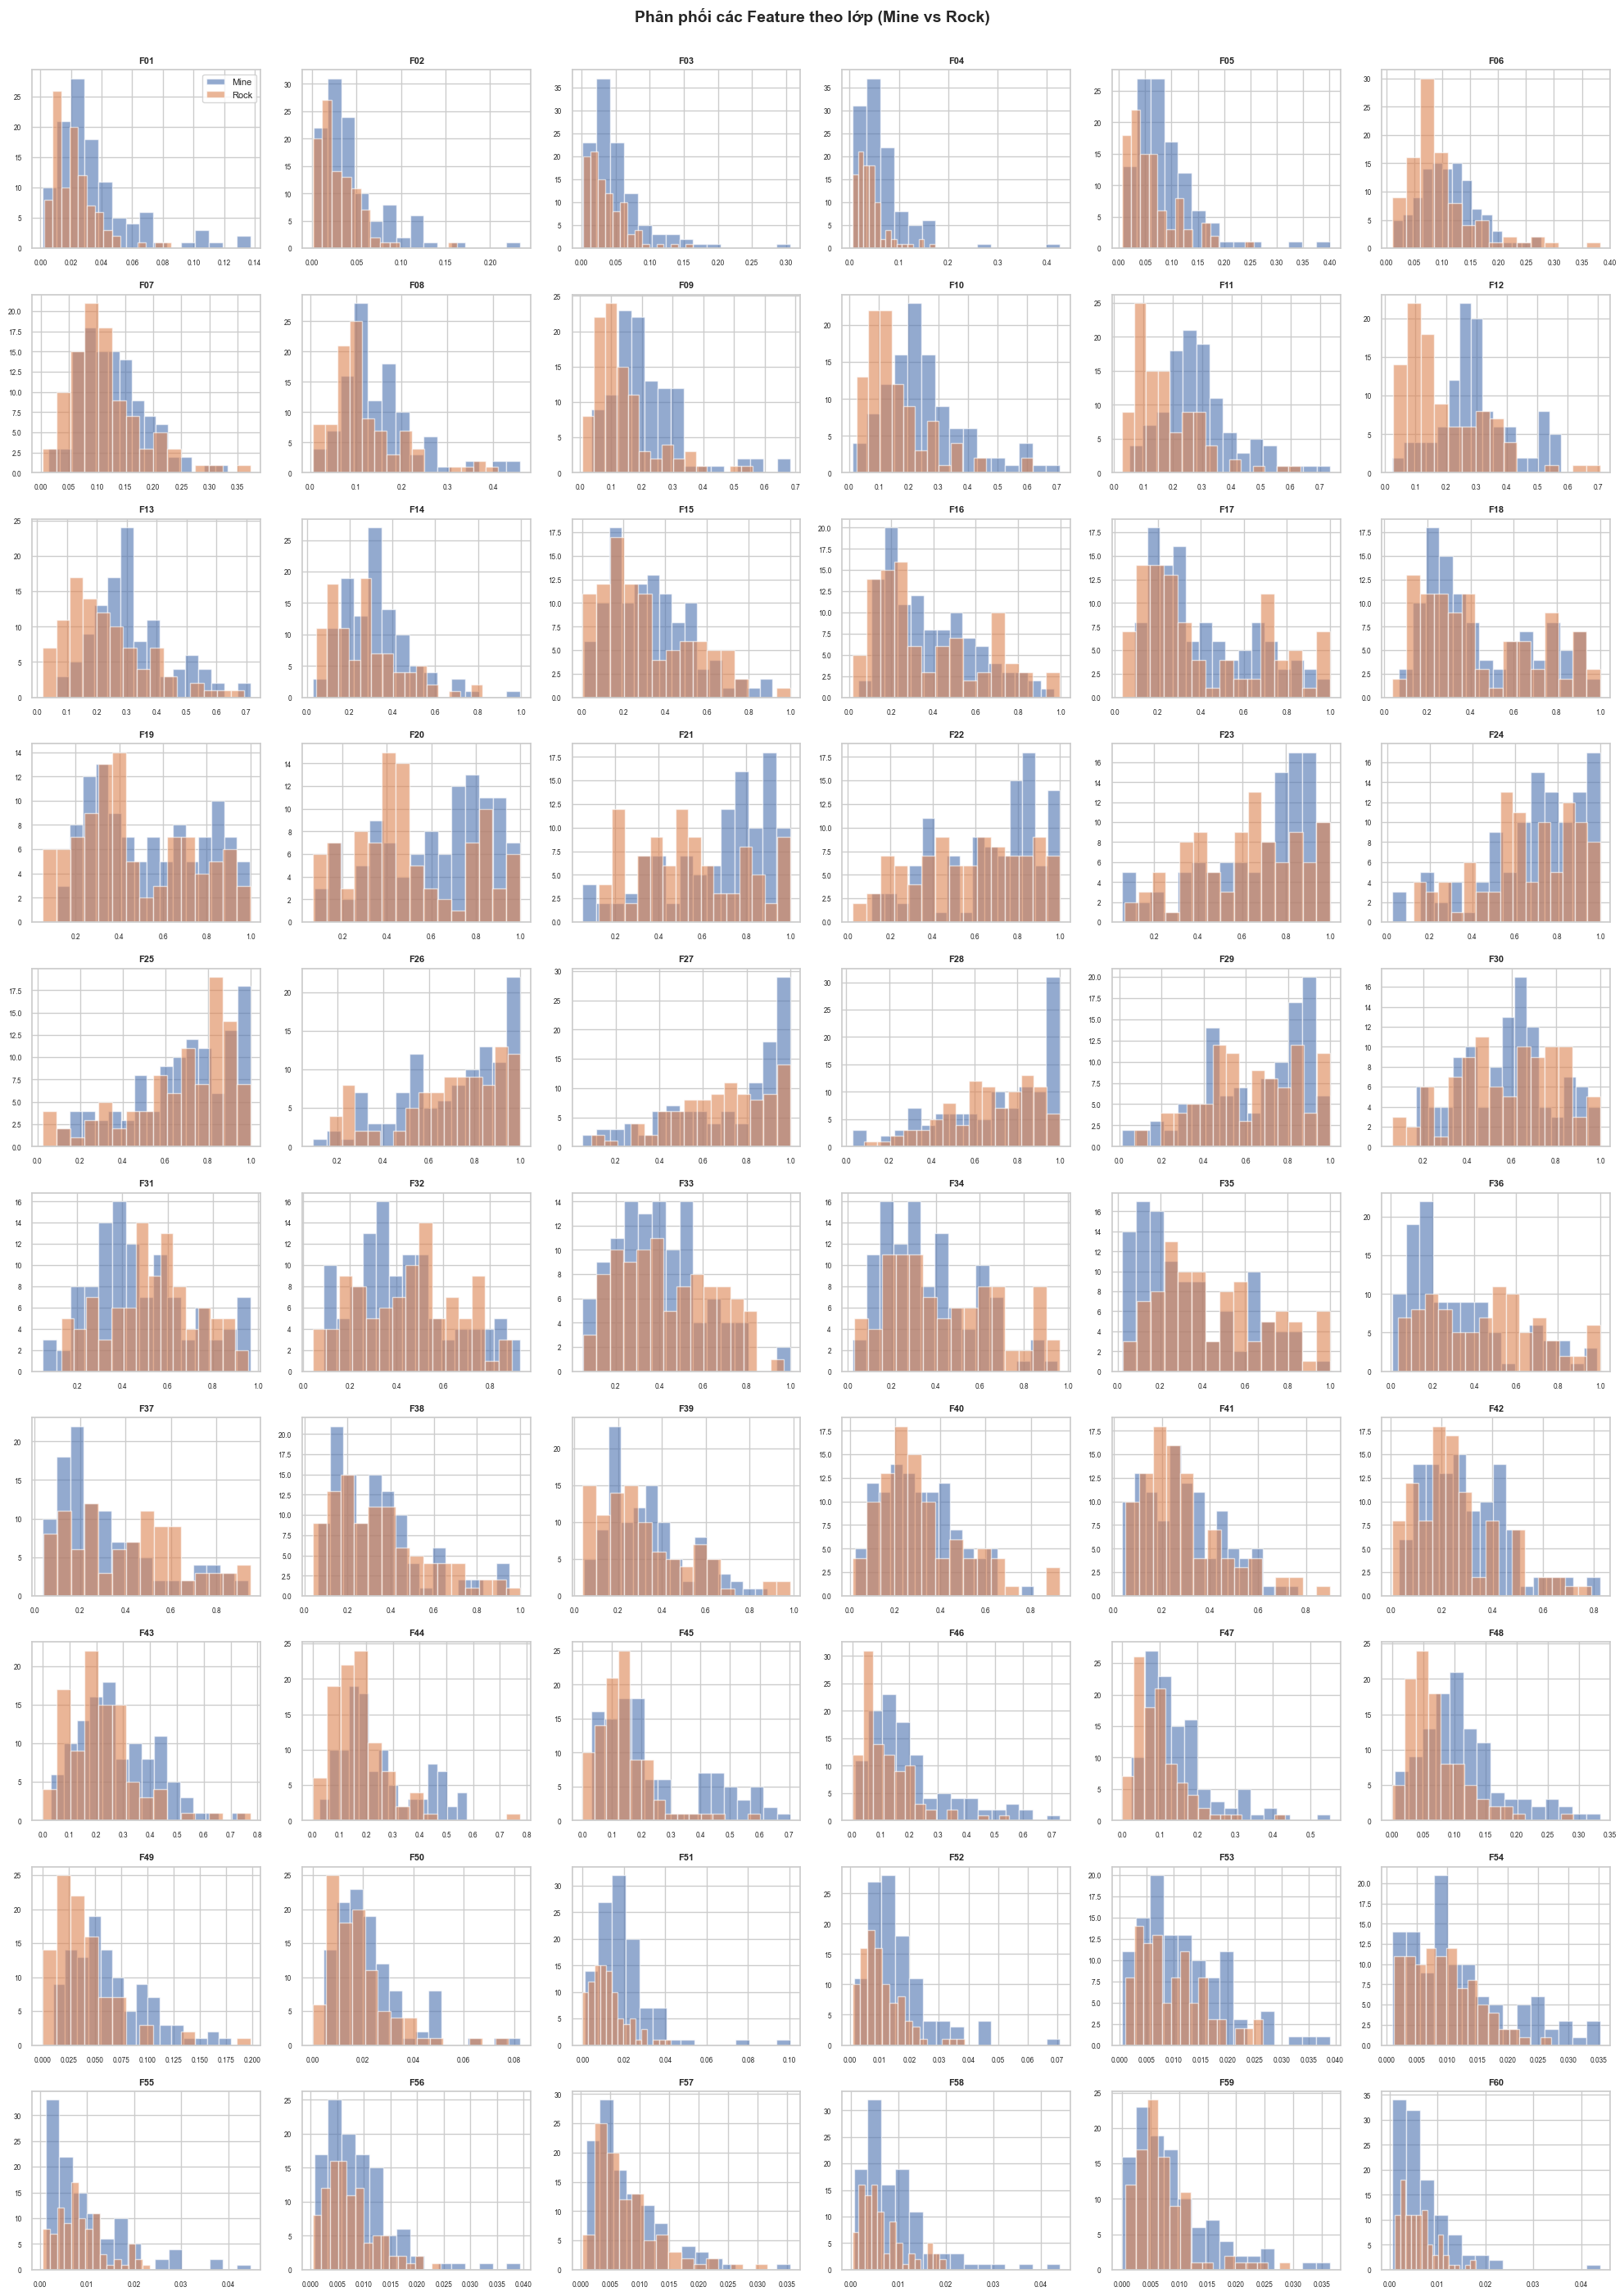

In [7]:
df_M = df[df['class'] == 'M'][FEATURES]
df_R = df[df['class'] == 'R'][FEATURES]

fig, axes = plt.subplots(10, 6, figsize=(20, 28))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df_M[feat], bins=15, alpha=0.6, label='Mine', color='#4C72B0', edgecolor='white')
    axes[i].hist(df_R[feat], bins=15, alpha=0.6, label='Rock', color='#DD8452', edgecolor='white')
    axes[i].set_title(feat, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=6)
axes[0].legend(fontsize=8)

plt.suptitle('Phân phối các Feature theo lớp (Mine vs Rock)', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_histogram.png'), bbox_inches='tight', dpi=100)
plt.show()

### 3.2.2. Boxplot - Phát hiện Outlier (sample features)

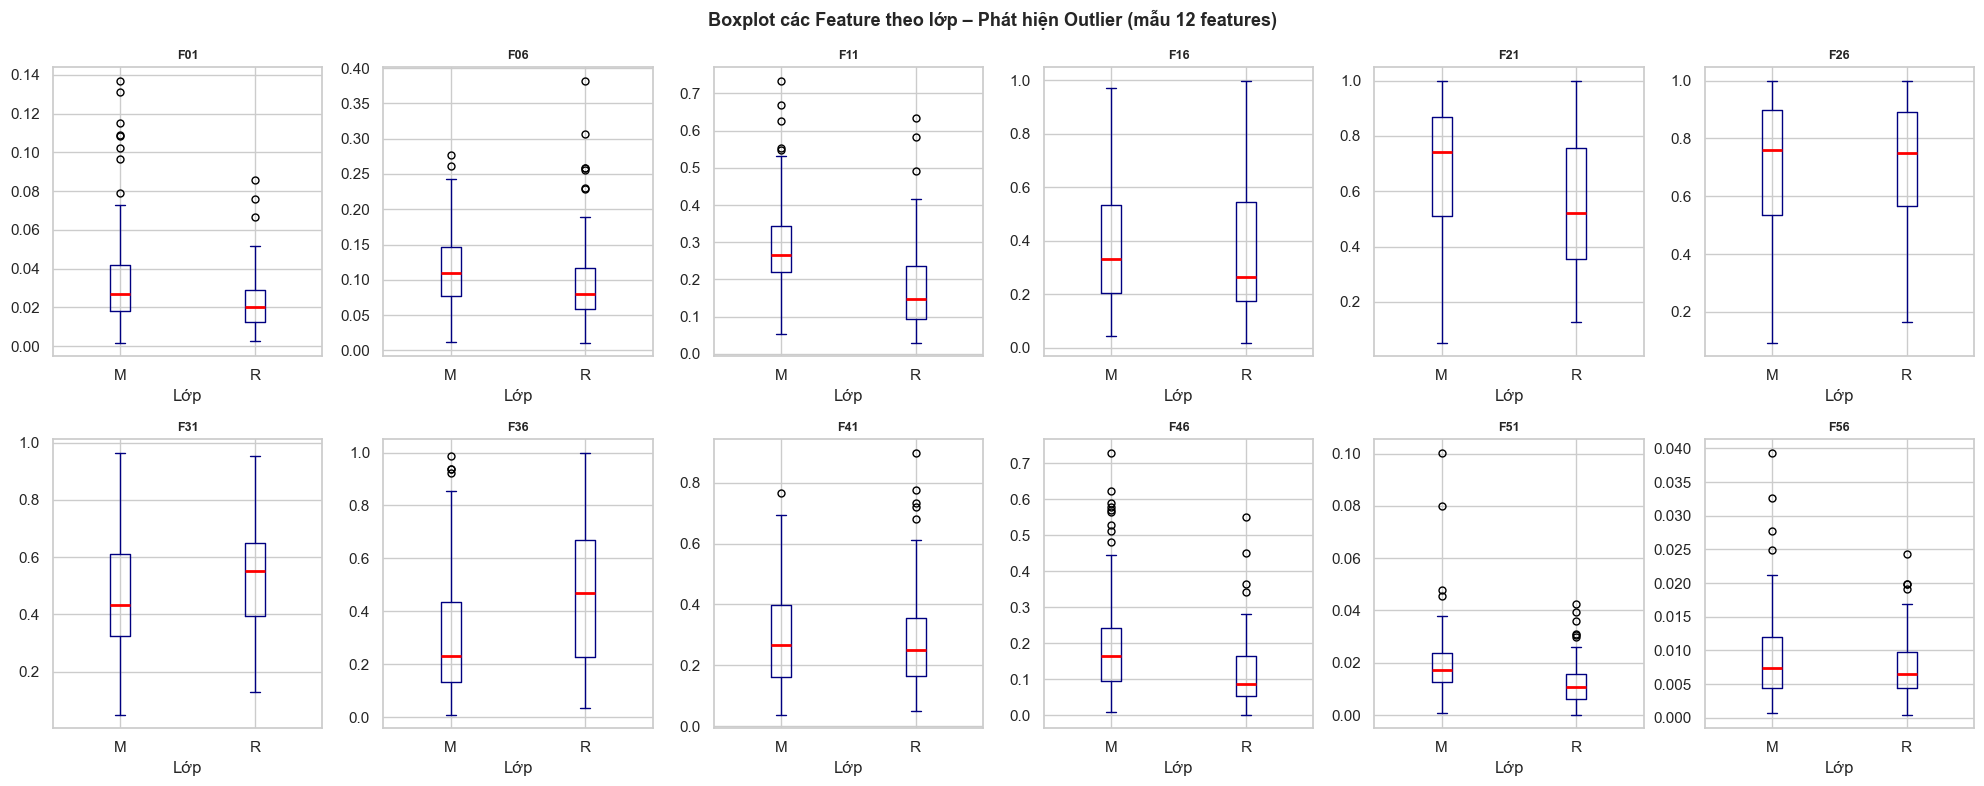

In [8]:
# Lấy mẫu 12 features trải đều
sample_feats = FEATURES[::5]  # F01, F06, F11, ...
df_melt = df[sample_feats + ['class']].melt(id_vars='class', var_name='Feature', value_name='Value')

fig, axes = plt.subplots(2, 6, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(sample_feats):
    df.boxplot(column=feat, by='class', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='navy'),
               capprops=dict(color='navy'),
               flierprops=dict(marker='o', color='orange', markersize=5))
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Lớp')

plt.suptitle('Boxplot các Feature theo lớp – Phát hiện Outlier (mẫu 12 features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_boxplot.png'), bbox_inches='tight')
plt.show()

### 3.2.3. Violin Plot

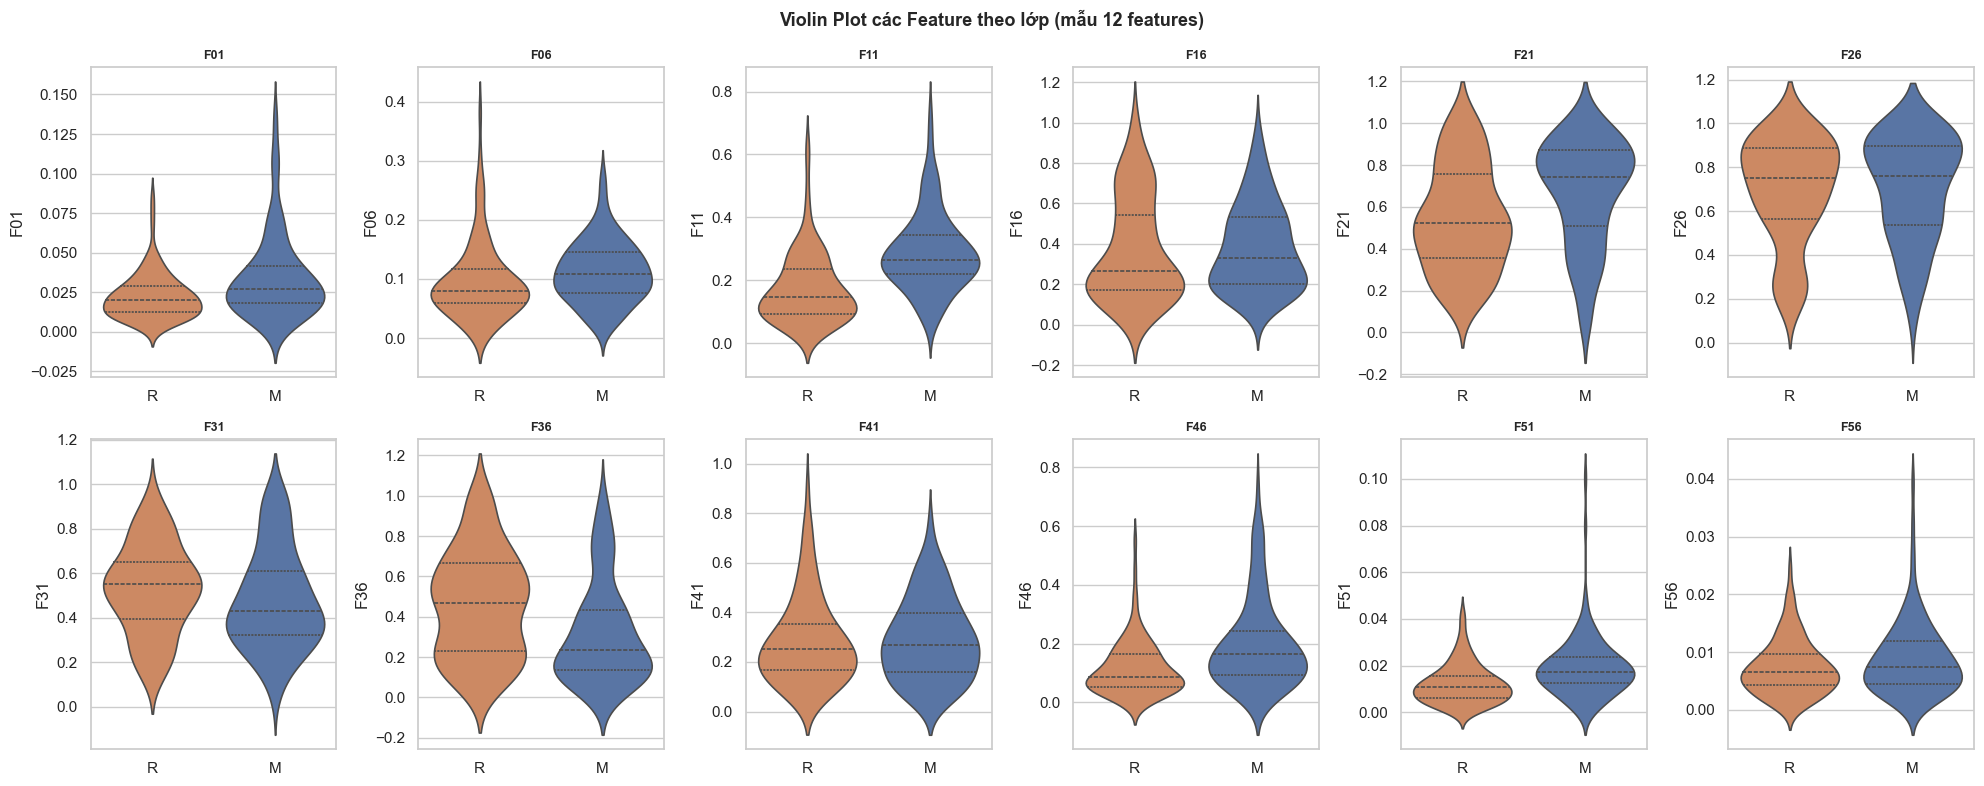

In [9]:
palette_cls = {'M': '#4C72B0', 'R': '#DD8452'}
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
axes = axes.flatten()
for i, feat in enumerate(sample_feats):
    sns.violinplot(data=df, x='class', y=feat, ax=axes[i],
                   palette=palette_cls, inner='quartile', linewidth=1.2)
    axes[i].set_title(feat, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Violin Plot các Feature theo lớp (mẫu 12 features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_violin.png'), bbox_inches='tight')
plt.show()

### 3.2.4. Giá trị trung bình từng Feature theo lớp

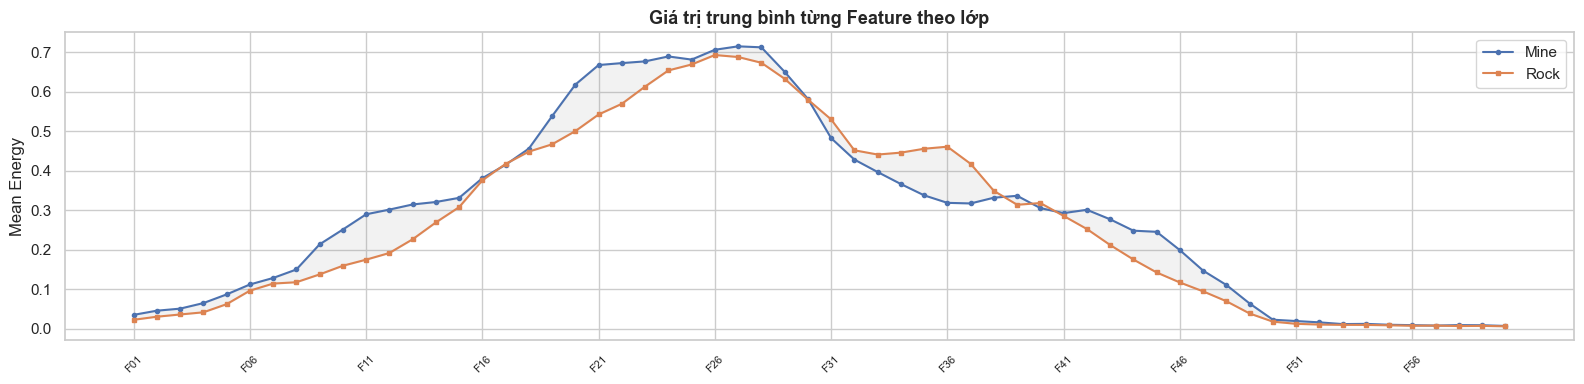

In [10]:
mean_M = df_M.mean()
mean_R = df_R.mean()

fig, ax = plt.subplots(figsize=(16, 4))
x = np.arange(len(FEATURES))
ax.plot(x, mean_M.values, label='Mine', marker='o', ms=3, lw=1.5, color='#4C72B0')
ax.plot(x, mean_R.values, label='Rock', marker='s', ms=3, lw=1.5, color='#DD8452')
ax.fill_between(x, mean_M.values, mean_R.values, alpha=0.1, color='gray')
ax.set_xticks(x[::5])
ax.set_xticklabels(FEATURES[::5], rotation=45, fontsize=8)
ax.set_title('Giá trị trung bình từng Feature theo lớp', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Energy')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_mean_by_class.png'), bbox_inches='tight')
plt.show()

### 3.2.5. Correlation Heatmap

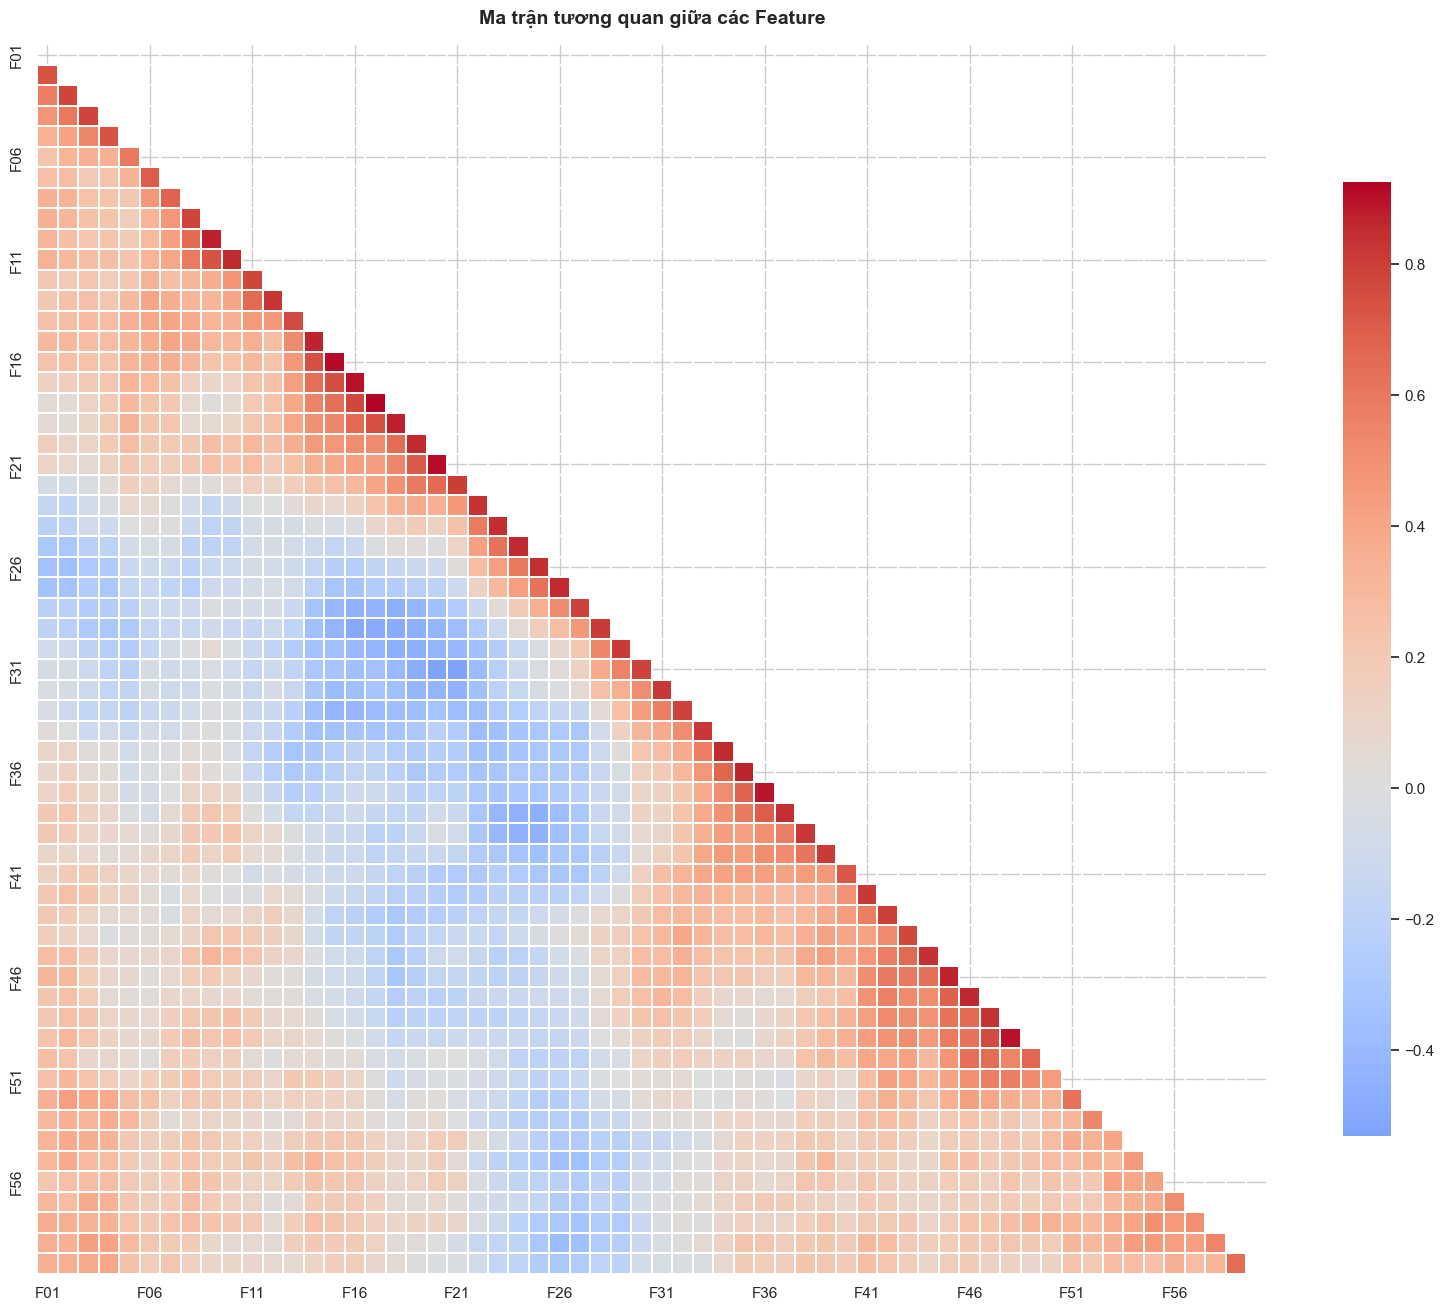


📌 Nhận xét:
  - Số cặp feature có |corr| > 0.9: 3
  - Các feature liền kề (tần số gần nhau) thường có tương quan cao


In [11]:
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.1, ax=ax,
            xticklabels=5, yticklabels=5,
            cbar_kws={'shrink': 0.7})
ax.set_title('Ma trận tương quan giữa các Feature', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_correlation.png'), bbox_inches='tight')
plt.show()

# Đếm cặp tương quan cao
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = abs(corr.iloc[i,j])
        if v > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(float(v),3)))
print(f'\n📌 Nhận xét:')
print(f'  - Số cặp feature có |corr| > 0.9: {len(high_corr)}')
print(f'  - Các feature liền kề (tần số gần nhau) thường có tương quan cao')

# 4. Chuẩn bị dữ liệu

## 4.1. Kiểm tra phân phối chuẩn (Shapiro-Wilk)

In [12]:
print('=== KIỂM TRA PHÂN PHỐI CHUẨN (Shapiro-Wilk) ===')
normal_count = 0
for feat in FEATURES:
    _, p = stats.shapiro(df[feat])
    if p > 0.05:
        normal_count += 1

print(f'Features đạt phân phối chuẩn (p>0.05): {normal_count} / {len(FEATURES)}')
print(f'Features KHÔNG đạt phân phối chuẩn   : {len(FEATURES)-normal_count} / {len(FEATURES)}')
print('→ Đa số features không phân phối chuẩn → StandardScaler vẫn phù hợp để chuẩn hóa')

=== KIỂM TRA PHÂN PHỐI CHUẨN (Shapiro-Wilk) ===
Features đạt phân phối chuẩn (p>0.05): 0 / 60
Features KHÔNG đạt phân phối chuẩn   : 60 / 60
→ Đa số features không phân phối chuẩn → StandardScaler vẫn phù hợp để chuẩn hóa


## 4.2. Chia dữ liệu Train/Test (7/3)

In [13]:
print('=== CHIA DỮ LIỆU TRAIN / TEST (7/3) ===')

X = df[FEATURES]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f'Tổng mẫu    : {len(df)}')
print(f'Train set   : {len(X_train)} mẫu ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set    : {len(X_test)}  mẫu ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nPhân phối train:\n{y_train.value_counts()}')
print(f'\nPhân phối test:\n{y_test.value_counts()}')

=== CHIA DỮ LIỆU TRAIN / TEST (7/3) ===
Tổng mẫu    : 208
Train set   : 145 mẫu (70%)
Test set    : 63  mẫu (30%)

Phân phối train:
class
M    77
R    68
Name: count, dtype: int64

Phân phối test:
class
M    34
R    29
Name: count, dtype: int64


## 4.3. Chuẩn hóa dữ liệu & Lưu file CSV

In [14]:
def save_split(X_tr, X_te, y_tr, y_te, train_path, test_path, scaler=None, scaler_name='raw'):
    """Chuẩn hóa (nếu cần) và lưu file train/test"""
    X_tr_s, X_te_s = X_tr.copy(), X_te.copy()
    if scaler is not None:
        X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr), columns=FEATURES, index=X_tr.index)
        X_te_s = pd.DataFrame(scaler.transform(X_te),     columns=FEATURES, index=X_te.index)

    train_df = pd.concat([X_tr_s, y_tr], axis=1)
    test_df  = pd.concat([X_te_s, y_te], axis=1)
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path,  index=False)
    print(f'✅ [{scaler_name:8s}] Train → {train_path}')
    print(f'✅ [{scaler_name:8s}] Test  → {test_path}')
    return train_df, test_df

# Raw
train_raw, test_raw = save_split(
    X_train, X_test, y_train, y_test,
    TRAIN_DATA_RAW, TEST_DATA_RAW, scaler_name='raw')

# MinMax
train_mm, test_mm = save_split(
    X_train, X_test, y_train, y_test,
    TRAIN_DATA_MM, TEST_DATA_MM,
    scaler=MinMaxScaler(), scaler_name='minmax')

# Standard
train_std, test_std = save_split(
    X_train, X_test, y_train, y_test,
    TRAIN_DATA_STD, TEST_DATA_STD,
    scaler=StandardScaler(), scaler_name='standard')

split_meta = {
    'dataset': DATA_NAME,
    'feature_count': len(FEATURES),
    'features': FEATURES,
    'target': 'class',
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'train_size': int(len(X_train)),
    'test_size_rows': int(len(X_test)),
    'exports': {
        'train_raw': TRAIN_DATA_RAW,
        'test_raw': TEST_DATA_RAW,
        'train_minmax': TRAIN_DATA_MM,
        'test_minmax': TEST_DATA_MM,
        'train_standard': TRAIN_DATA_STD,
        'test_standard': TEST_DATA_STD,
    }
}
with open(SPLIT_META, 'w', encoding='utf-8') as f:
    json.dump(split_meta, f, ensure_ascii=False, indent=2)

custom_template = pd.DataFrame(columns=FEATURES + ['class'])
custom_template.to_csv(CUSTOM_TEMPLATE, index=False)

print() 
print('📦 ĐÃ CHUẨN HÓA CÁCH XUẤT FILE CHO FLOW MỚI')
print(f'   {TRAIN_DATA_RAW}')
print(f'   {TEST_DATA_RAW}')
print(f'   {TRAIN_DATA_MM}')
print(f'   {TEST_DATA_MM}')
print(f'   {TRAIN_DATA_STD}')
print(f'   {TEST_DATA_STD}')
print(f'   {SPLIT_META}')
print(f'   {CUSTOM_TEMPLATE}  ← file mẫu để thêm dữ liệu test thủ công')


✅ [raw     ] Train → D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_raw.csv
✅ [raw     ] Test  → D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_raw.csv
✅ [minmax  ] Train → D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_minmax.csv
✅ [minmax  ] Test  → D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_minmax.csv
✅ [standard] Train → D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_standard.csv
✅ [standard] Test  → D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_standard.csv

📦 ĐÃ CHUẨN HÓA CÁCH XUẤT FILE CHO FLOW MỚI
   D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_raw.csv
   D:\HOCTAP\HK5\CSTTNT

✅ [minmax  ] Train → D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_minmax.csv
✅ [minmax  ] Test  → D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_minmax.csv
✅ [standard] Train → D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_standard.csv
✅ [standard] Test  → D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_standard.csv

📦 ĐÃ CHUẨN HÓA CÁCH XUẤT FILE CHO FLOW MỚI
   D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_raw.csv
   D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_raw.csv
   D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_minmax.csv
   D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_minmax.csv
   D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\train_standard.csv
   D:\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\test_standard.csv
   D:\final-project-CSTTNT-\Sonar_Ret

## 4.4. So sánh phân phối trước/sau chuẩn hóa

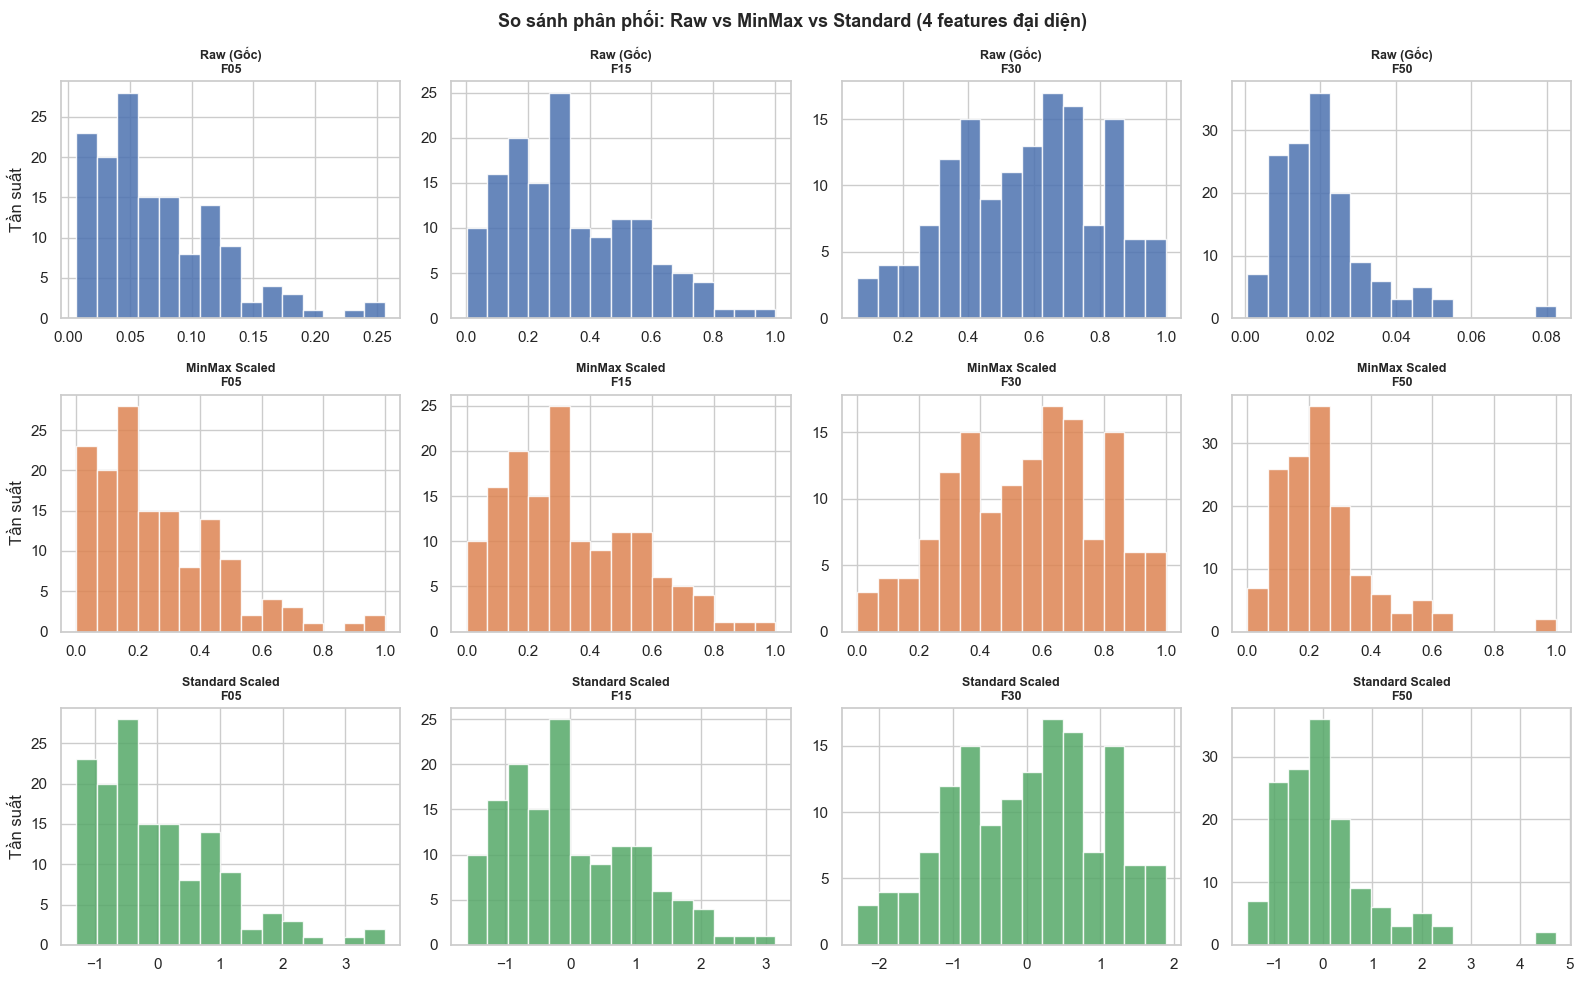

In [15]:
# Hiển thị 4 features đại diện
show_feats  = ['F05', 'F15', 'F30', 'F50']
titles      = ['Raw (Gốc)', 'MinMax Scaled', 'Standard Scaled']
datasets    = [train_raw, train_mm, train_std]
row_colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for row, (title, data, col) in enumerate(zip(titles, datasets, row_colors)):
    for c, feat in enumerate(show_feats):
        axes[row, c].hist(data[feat], bins=15, color=col, edgecolor='white', alpha=0.85)
        axes[row, c].set_title(f'{title}\n{feat}', fontsize=9, fontweight='bold')
        axes[row, c].set_ylabel('Tần suất' if c == 0 else '')

plt.suptitle('So sánh phân phối: Raw vs MinMax vs Standard (4 features đại diện)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'plot_scaling_compare.png'), bbox_inches='tight')
plt.show()

# 5. Ghi kết quả EDA vào Excel

In [16]:
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Sheet 1: Thông tin chung
df_info = pd.DataFrame({
    'Thông tin': ['Thời gian chạy', 'File dữ liệu', 'Số dòng', 'Số cột',
                  'Số lớp', 'Missing values', 'Duplicates', 'Tỉ lệ split'],
    'Giá trị':  [timestamp, DATA_PATH,
                 df.shape[0], df.shape[1],
                 df['class'].nunique(), df.isnull().sum().sum(),
                 df.duplicated().sum(), f'Train {1-TEST_SIZE:.0%} / Test {TEST_SIZE:.0%}']
})

# Sheet 2: Thống kê mô tả
df_stats = df[FEATURES].describe().round(4).reset_index().rename(columns={'index': 'Thống kê'})

# Sheet 3: Missing values
df_miss = pd.DataFrame({
    'Cột':      df.columns,
    'Số thiếu': df.isnull().sum().values,
    '% thiếu':  (df.isnull().sum() / len(df) * 100).round(2).values
})

# Sheet 4: Phân phối lớp
df_class = df['class'].value_counts().reset_index()
df_class.columns = ['Lớp', 'Số lượng']
df_class['Tỉ lệ %'] = (df_class['Số lượng'] / len(df) * 100).round(2)

# Sheet 5: Train/Test split info
df_split = pd.DataFrame({
    'Tập':    ['Train (raw)', 'Test (raw)', 'Train (minmax)', 'Test (minmax)',
               'Train (standard)', 'Test (standard)'],
    'File':   [TRAIN_DATA_RAW, TEST_DATA_RAW, TRAIN_DATA_MM,
               TEST_DATA_MM, TRAIN_DATA_STD, TEST_DATA_STD],
    'Số mẫu': [len(X_train), len(X_test)] * 3,
})

# Ghi Excel – luôn ghi đè toàn bộ file (tránh lỗi if_sheet_exists trên openpyxl cũ)
# Nếu file đã tồn tại thì đọc lịch sử sheet Thong_tin_chung trước
if os.path.exists(EDA_LOG):
    try:
        df_old     = pd.read_excel(EDA_LOG, sheet_name='Thong_tin_chung')
        df_history = pd.concat([df_old, df_info], ignore_index=True)
        is_new     = False
    except Exception:
        df_history = df_info
        is_new     = True
else:
    df_history = df_info
    is_new     = True

# Ghi đè toàn bộ file (mode='w' luôn an toàn)
with pd.ExcelWriter(EDA_LOG, engine='openpyxl', mode='w') as writer:
    df_history.to_excel(writer, sheet_name='Thong_tin_chung',  index=False)
    df_stats.to_excel(writer,   sheet_name='Thong_ke_mo_ta',   index=False)
    df_miss.to_excel(writer,    sheet_name='Missing_Values',   index=False)
    df_class.to_excel(writer,   sheet_name='Phan_phoi_lop',    index=False)
    df_split.to_excel(writer,   sheet_name='Train_Test_Split', index=False)

label = 'Tao file moi' if is_new else 'Cap nhat file'
print(f'{label}: {EDA_LOG}')
print('Da ghi eda_log.xlsx (5 sheets)')

Cap nhat file: D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar\eda_log.xlsx
Da ghi eda_log.xlsx (5 sheets)


# 6. Tổng kết EDA

In [17]:
print('=' * 70)
print('TỔNG KẾT EDA - FLOW SONAR THỐNG NHẤT')
print('=' * 70)
print(f'Dataset      : {DATA_NAME}.csv')
print(f'Số features  : {len(FEATURES)}')
print(f'Train/Test   : {(1-TEST_SIZE):.0%} / {TEST_SIZE:.0%}')
print(f'Thư mục xuất : {PROJECT_DIR}')
print()
print('Các file chính:')
for fp in [TRAIN_DATA_RAW, TEST_DATA_RAW, TRAIN_DATA_MM, TEST_DATA_MM,
           TRAIN_DATA_STD, TEST_DATA_STD, EDA_LOG, SPLIT_META, CUSTOM_TEMPLATE]:
    print(' -', os.path.basename(fp))
print('=' * 70)
print('➡ Bước tiếp theo: chạy 02_train.ipynb để chọn model tốt nhất')


TỔNG KẾT EDA - FLOW SONAR THỐNG NHẤT
Dataset      : sonar.csv
Số features  : 60
Train/Test   : 70% / 30%
Thư mục xuất : D:\HOCTAP\HK5\CSTTNT\Bao_cao_cuoi_ki\final-project-CSTTNT-\Sonar_Return(Project_Final)\exps_\sonar

Các file chính:
 - train_raw.csv
 - test_raw.csv
 - train_minmax.csv
 - test_minmax.csv
 - train_standard.csv
 - test_standard.csv
 - eda_log.xlsx
 - split_metadata.json
 - custom_test_template.csv
➡ Bước tiếp theo: chạy 02_train.ipynb để chọn model tốt nhất
